ugesh kc


2431328

# 6CS012 - Worksheet 5: End-to-End CNN Model for Fruit Image Classification

This notebook implements a CNN model to classify Amazon fruits using TensorFlow and Keras.

## Setup: Import Libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Configuration

In [ ]:
train_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/FruitinAmazon/test"

IMG_HEIGHT = 128
IMG_WIDTH  = 128
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
EPOCHS = 250

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Task 1: Data Understanding and Visualization

### 1a. Visualize One Image Per Class

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


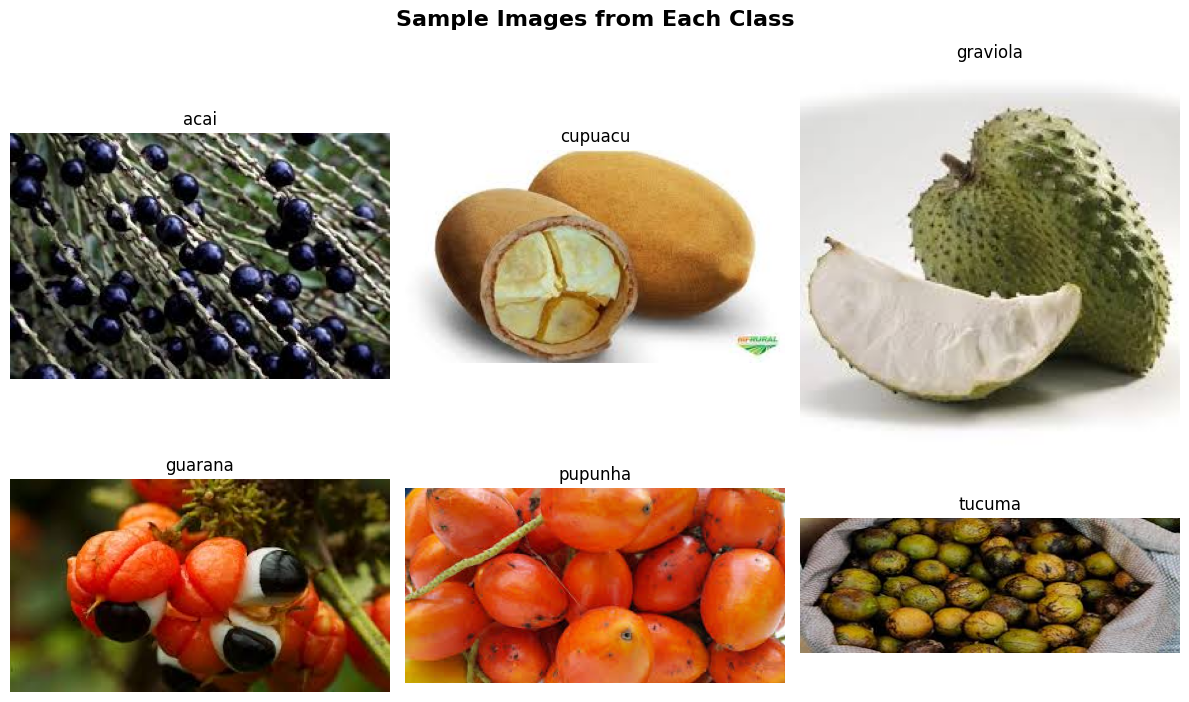

In [ ]:
# Get list of class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"Classes found ({len(class_dirs)}): {class_dirs}")

# Select one random image from each class
class_images = {}
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        class_images[cls] = os.path.join(cls_path, random.choice(images))

# Display images in a grid with 2 rows
num_classes = len(class_images)
cols = (num_classes + 1) // 2  # number of columns for 2 rows
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for idx, (cls_name, img_path) in enumerate(class_images.items()):
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls_name, fontsize=12)
    axes[idx].axis('off')

# Hide any unused subplots
for idx in range(len(class_images), len(axes)):
    axes[idx].axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- The dataset contains images of different Amazon fruit classes.
- Images vary in size, background, lighting conditions, and orientation.
- Some classes may have more distinctive visual features than others.

### 1b. Check for Corrupted Images

In [ ]:
corrupted_images = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()  # Verify it is a valid image
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


---
## Task 2: Loading and Preprocessing Image Data

In [ ]:
# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)

# Get class names BEFORE mapping
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

# Rescaling layer
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# Apply normalization AFTER
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [ ]:
# Test dataset (loaded separately without split)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


---
## Task 3: Build the CNN Model

In [ ]:
model = keras.Sequential([
    # --- Convolutional Block 1 ---
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1,
                  activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # --- Convolutional Block 2 ---
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1,
                  activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # --- Fully Connected Network ---
    layers.Flatten(),
    layers.Dense(128, activation='relu'),   # Hidden Layer 1
    layers.Dense(64,  activation='relu'),   # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
], name="Fruit_CNN")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile and Train the Model

In [ ]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=16,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.1244 - loss: 2.1588
Epoch 1: val_accuracy improved from None to 0.55556, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 940ms/step - accuracy: 0.1389 - loss: 2.3139 - val_accuracy: 0.5556 - val_loss: 1.6235
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.4120 - loss: 1.8303
Epoch 2: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.3611 - loss: 1.8369 - val_accuracy: 0.3333 - val_loss: 1.7154
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.5110 - loss: 1.5656
Epoch 3: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 0.4861 - loss: 1.5645 - val_accuracy: 0.2222 - val_loss: 1.7072
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.5284 - loss: 1.3969
Epoch 4: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 0.5694 - loss: 1.3631 - val_accuracy: 0.3889 - val_loss: 1.4233
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.5804 - loss: 1.133


Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 504ms/step - accuracy: 0.5694 - loss: 1.1262 - val_accuracy: 0.7778 - val_loss: 0.8697
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7957 - loss: 0.8784
Epoch 6: val_accuracy improved from 0.77778 to 0.88889, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 573ms/step - accuracy: 0.7778 - loss: 0.8763 - val_accuracy: 0.8889 - val_loss: 0.8961
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9010 - loss: 0.5714
Epoch 7: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 0.8750 - loss: 0.5669 - val_accuracy: 0.7222 - val_loss: 0.8122
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8646 - loss: 0.4281
Epoch 8: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 756ms/step - accuracy: 0.8750 - loss: 0.4327 - val_accuracy: 0.8333 - val_loss: 0.6804
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.9595 - loss: 0.2790
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 744ms/step - accuracy: 0.9722 - loss: 0.2669 - val_accuracy: 0.8333 - val_loss: 0.4378
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9601 - loss: 0.25


Epoch 14: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - accuracy: 1.0000 - loss: 0.0380 - val_accuracy: 0.9444 - val_loss: 0.4319
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 1.0000 - loss: 0.0251
Epoch 15: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 767ms/step - accuracy: 1.0000 - loss: 0.0225 - val_accuracy: 0.8333 - val_loss: 0.4646
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 1.0000 - loss: 0.0079
Epoch 16: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 707ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.8333 - val_loss: 0.5916
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 1.0000 - loss: 0.0105
Epoch 17: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 456ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 0.7778 - val_loss: 0.5991
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 1.0000 - los

### Training & Validation Curves

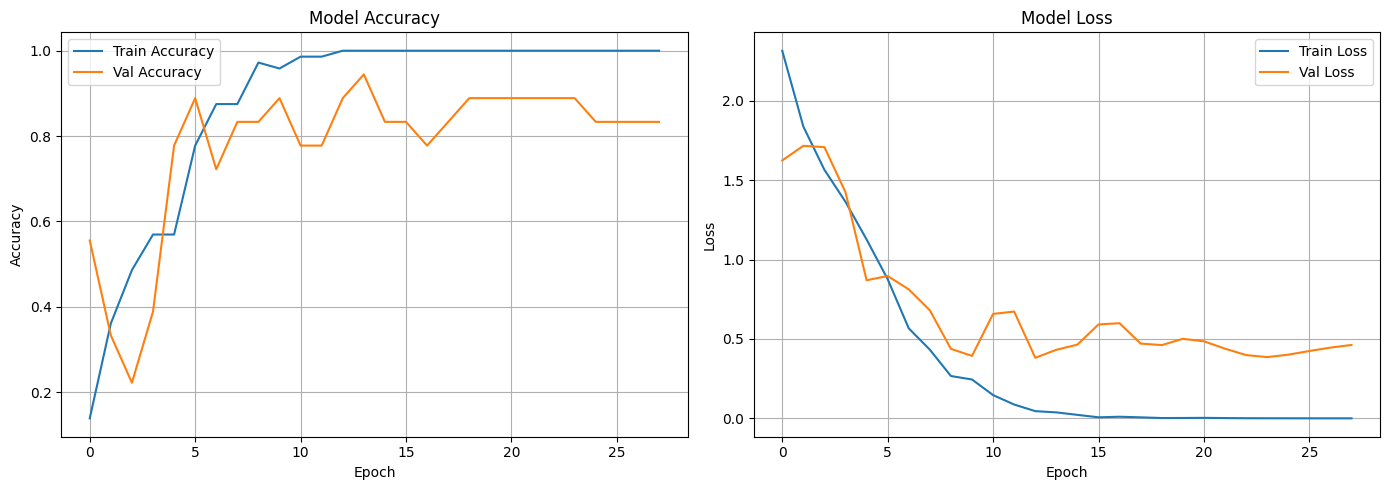

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

---
## Task 5: Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 1.4053

Test Loss    : 1.4053
Test Accuracy: 0.5000


---
## Task 6: Save and Load the Model

In [ ]:
# Save the model
model.save('fruit_cnn_model.h5')
print("Model saved to fruit_cnn_model.h5")

# Load the saved model
loaded_model = keras.models.load_model('fruit_cnn_model.h5')
print("Model loaded successfully.")

# Re-evaluate on the test set
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"\nLoaded Model Test Loss    : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

Model saved to fruit_cnn_model.h5
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step - accuracy: 0.5000 - loss: 1.4053

Loaded Model Test Loss    : 1.4053
Loaded Model Test Accuracy: 0.5000


---
## Task 7: Predictions and Classification Report

In [ ]:
# Collect all true labels and predictions from test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    probs = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

        acai       0.40      0.80      0.53         5
     cupuacu       0.57      0.80      0.67         5
    graviola       1.00      0.80      0.89         5
     guarana       0.00      0.00      0.00         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.25      0.40      0.31         5

    accuracy                           0.50        30
   macro avg       0.54      0.50      0.45        30
weighted avg       0.54      0.50      0.45        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


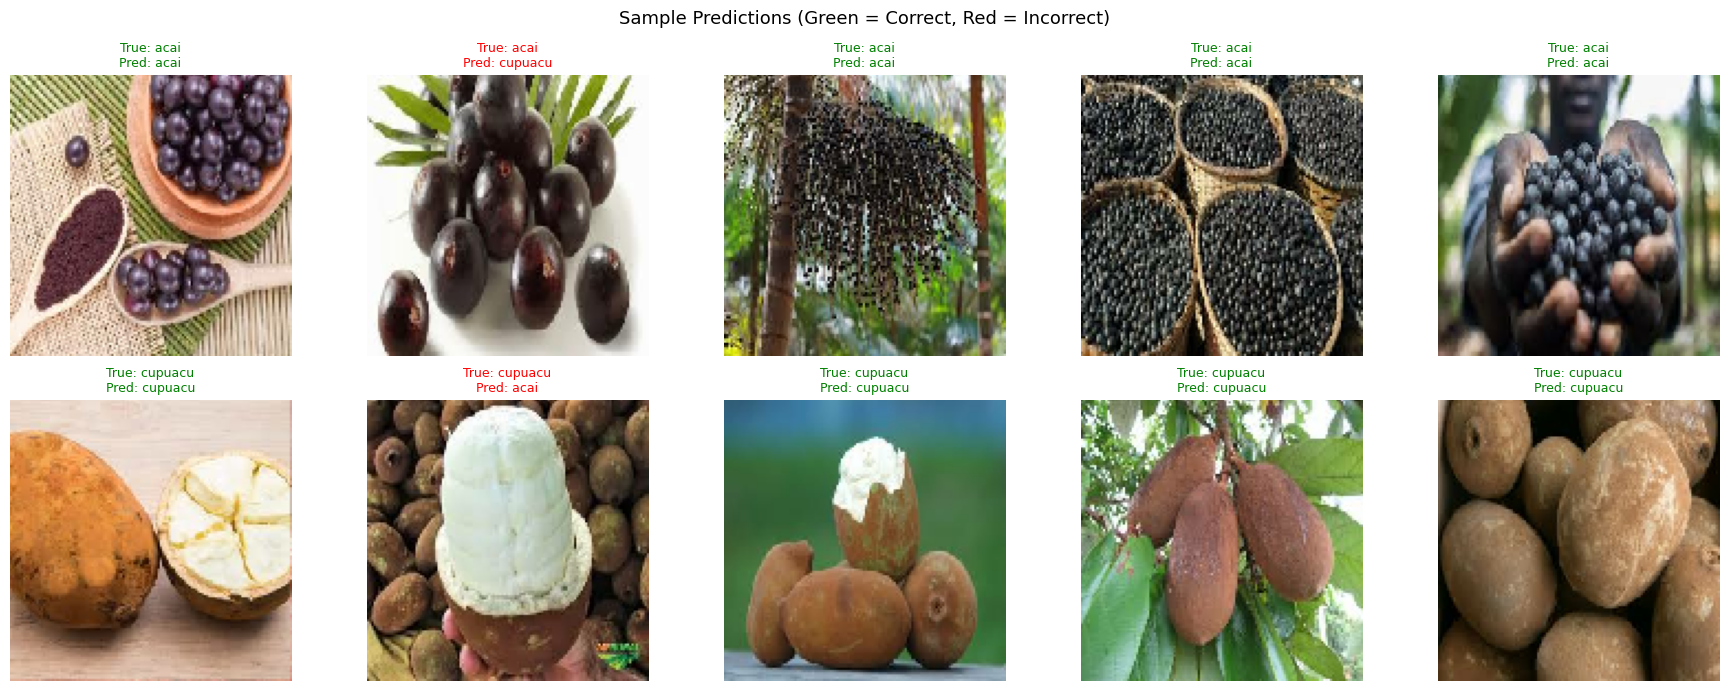

In [ ]:
# Visualise a few test predictions
sample_images, sample_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_images, verbose=0), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i in range(min(10, len(sample_images))):
    axes[i].imshow(sample_images[i].numpy())
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[sample_preds[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample Predictions (Green = Correct, Red = Incorrect)", fontsize=13)
plt.tight_layout()
plt.show()